In [6]:
import sys
sys.path.append("..")
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import src.black_scholes as bs
import src.hedging as hd
importlib.reload(hd)

S0, K, T, r = 100.0, 100.0, 1 / 12, 0.04   # call ATM à 1 mois
sigma_imp = 0.20                            # vol à laquelle l'option est vendue
mu = 0.08                                   # tendance de l'action (ne devrait pas compter !)
n_paths = 10_000

prime = bs.bs_price(S0, K, T, r, sigma_imp, "call")
print(f"Prime encaissée pour le call ATM 1 mois à 20 % de vol : {prime:.4f}")

Prime encaissée pour le call ATM 1 mois à 20 % de vol : 2.4694


In [7]:
rows = []
for n_steps, label in [(4, "hebdomadaire"), (21, "quotidienne"), (84, "4 fois par jour"), (336, "≈ toutes les heures")]:
    paths = hd.simulate_gbm(S0, mu, sigma_imp, T, n_steps, n_paths, seed=1)
    pnl = hd.delta_hedge_pnl(paths, K, T, r, sigma_imp)
    rows.append({"couverture": label, "nb_rebalancements": n_steps,
                 "P&L moyen": pnl.mean(), "écart-type": pnl.std(),
                 "écart-type / prime": pnl.std() / prime})
print(pd.DataFrame(rows).round(4).to_string(index=False))

         couverture  nb_rebalancements  P&L moyen  écart-type  écart-type / prime
       hebdomadaire                  4     0.0169      0.9318              0.3774
        quotidienne                 21     0.0010      0.4309              0.1745
    4 fois par jour                 84     0.0042      0.2186              0.0885
≈ toutes les heures                336     0.0014      0.1096              0.0444


 nb_rebalancements  coût moyen  risque (écart-type)
                 4      0.0843               0.9286
                10      0.0977               0.6150
                21      0.1265               0.4347
                42      0.1546               0.3163
                84      0.1981               0.2284
               168      0.2586               0.1786
               336      0.3422               0.1580


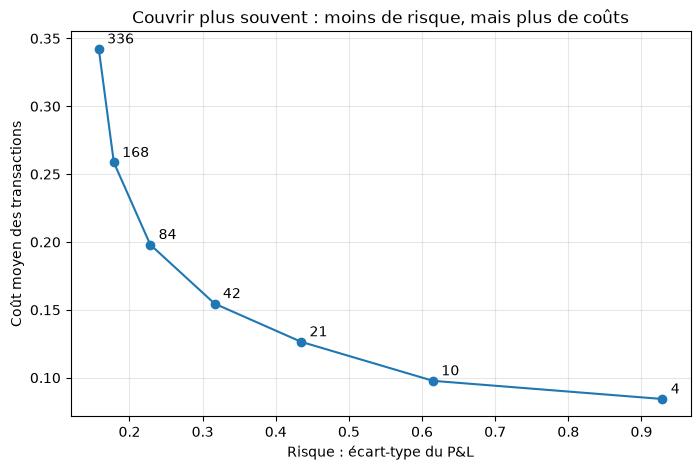

In [8]:
cost = 0.0005   # 5 points de base du montant échangé à chaque transaction
rows = []
for n_steps in [4, 10, 21, 42, 84, 168, 336]:
    paths = hd.simulate_gbm(S0, mu, sigma_imp, T, n_steps, n_paths, seed=4)
    pnl = hd.delta_hedge_pnl(paths, K, T, r, sigma_imp, cost=cost)
    rows.append({"nb_rebalancements": n_steps, "coût moyen": -pnl.mean(), "risque (écart-type)": pnl.std()})
costs = pd.DataFrame(rows)
print(costs.round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(costs["risque (écart-type)"], costs["coût moyen"], "o-")
for _, row in costs.iterrows():
    ax.annotate(f"{row['nb_rebalancements']:.0f}", (row["risque (écart-type)"], row["coût moyen"]),
                textcoords="offset points", xytext=(6, 4))
ax.set_xlabel("Risque : écart-type du P&L")
ax.set_ylabel("Coût moyen des transactions")
ax.set_title("Couvrir plus souvent : moins de risque, mais plus de coûts")
ax.grid(alpha=0.3)
fig.savefig("../figures/hedging_cost_vs_risk.png", dpi=150, bbox_inches="tight")
plt.show()

Vol réalisée 15% | P&L moyen = +0.5746 | attendu ≈ +0.5753 | écart-type = 0.3743
Vol réalisée 20% | P&L moyen = -0.0006 | attendu ≈ +0.0000 | écart-type = 0.4320
Vol réalisée 25% | P&L moyen = -0.5780 | attendu ≈ -0.5757 | écart-type = 0.5914


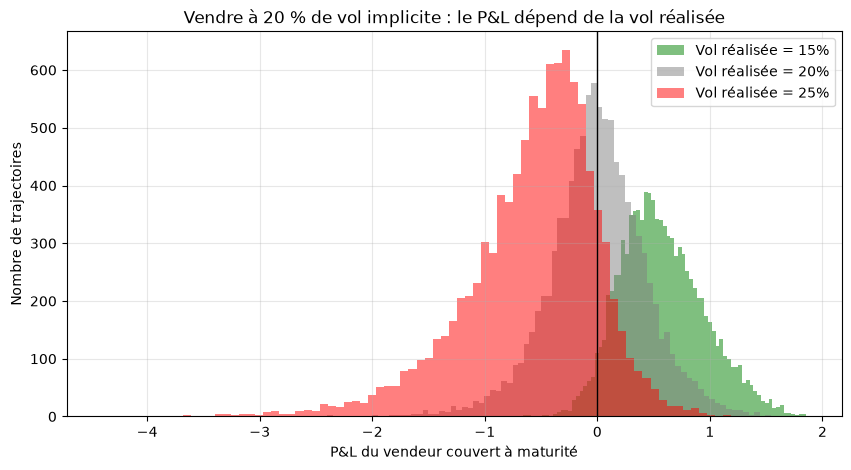

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
for sigma_real, color in [(0.15, "green"), (0.20, "grey"), (0.25, "red")]:
    paths = hd.simulate_gbm(S0, mu, sigma_real, T, 21, n_paths, seed=2)
    pnl = hd.delta_hedge_pnl(paths, K, T, r, sigma_imp)
    attendu = (bs.bs_price(S0, K, T, r, sigma_imp, "call") - bs.bs_price(S0, K, T, r, sigma_real, "call")) * np.exp(r * T)
    print(f"Vol réalisée {sigma_real:.0%} | P&L moyen = {pnl.mean():+.4f} | "
          f"attendu ≈ {attendu:+.4f} | écart-type = {pnl.std():.4f}")
    ax.hist(pnl, bins=80, alpha=0.5, color=color, label=f"Vol réalisée = {sigma_real:.0%}")

ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("P&L du vendeur couvert à maturité")
ax.set_ylabel("Nombre de trajectoires")
ax.set_title("Vendre à 20 % de vol implicite : le P&L dépend de la vol réalisée")
ax.legend()
ax.grid(alpha=0.3)
fig.savefig("../figures/hedging_pnl_vs_realised.png", dpi=150, bbox_inches="tight")
plt.show()

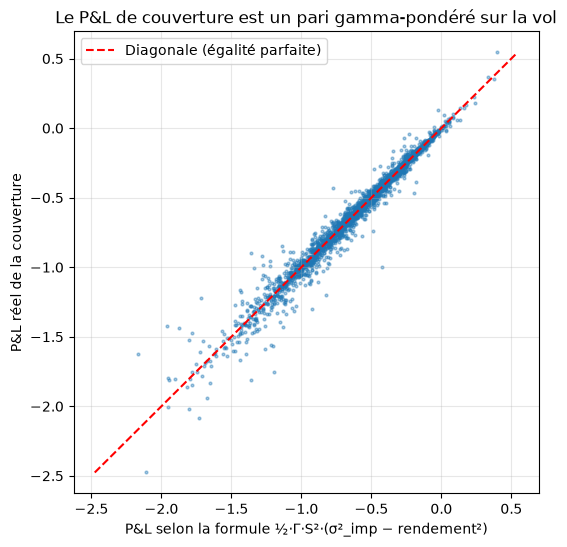

Corrélation entre P&L réel et formule : 0.9870


In [10]:
paths = hd.simulate_gbm(S0, mu, 0.25, T, 84, 3_000, seed=3)
pnl_reel = hd.delta_hedge_pnl(paths, K, T, r, sigma_imp)
pnl_formule = hd.gamma_pnl_approx(paths, K, T, r, sigma_imp)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(pnl_formule, pnl_reel, s=4, alpha=0.4)
lims = [min(pnl_formule.min(), pnl_reel.min()), max(pnl_formule.max(), pnl_reel.max())]
ax.plot(lims, lims, "r--", label="Diagonale (égalité parfaite)")
ax.set_xlabel("P&L selon la formule ½·Γ·S²·(σ²_imp − rendement²)")
ax.set_ylabel("P&L réel de la couverture")
ax.set_title("Le P&L de couverture est un pari gamma-pondéré sur la vol")
ax.legend()
ax.grid(alpha=0.3)
fig.savefig("../figures/hedging_gamma_formula.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Corrélation entre P&L réel et formule : {np.corrcoef(pnl_formule, pnl_reel)[0, 1]:.4f}")